In [ ]:

%pip -q install timm==0.9.2 einops

import os, random, gc, math
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from einops import rearrange
import timm


def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| Torch:", torch.__version__)


Device: cuda | Torch: 2.8.0+cu126


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


TRAIN_IMG_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/image_RGB"
TRAIN_MASK_DIR = "/content/drive/MyDrive/Dataset/GIDsplit/train/label"
VAL_IMG_DIR   = "/content/drive/MyDrive/Dataset/GIDsplit/val/image_RGB"
VAL_MASK_DIR  = "/content/drive/MyDrive/Dataset/GIDsplit/val/label"


CLASS_COLORS = [
    (0,0,0),        # 0 background
    (255,0,0),      # 1 build-up
    (255,255,0),    # 2 farmland
    (0,255,0),      # 3 forest
    (0,255,255),    # 4 meadow
    (0,0,255),      # 5 water
]
CLASS_NAMES = ["background","build-up","farmland","forest","meadow","water"]
NUM_CLASSES = len(CLASS_COLORS)


NORM_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
NORM_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

IMG_EXTS  = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
MASK_EXTS = [".png",".tif",".tiff",".jpg",".jpeg",".bmp"]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def list_images(folder: str|Path):
    p = Path(folder)
    return [x for x in sorted(p.iterdir()) if x.suffix.lower() in IMG_EXTS]

def rgb_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    out = np.zeros(mask_rgb.shape[:2], dtype=np.int64)
    for k,(r,g,b) in enumerate(CLASS_COLORS):
        m = (mask_rgb[...,0]==r) & (mask_rgb[...,1]==g) & (mask_rgb[...,2]==b)
        out[m] = k
    return out

def mask_to_class_any(mask_pil: Image.Image) -> np.ndarray:
    if mask_pil.mode in ("I;16","I","L"):
        return np.array(mask_pil, dtype=np.int64)
    else:
        return rgb_to_class(np.array(mask_pil.convert("RGB"), dtype=np.uint8))

def colorize_idx(idx_hw):
    if hasattr(idx_hw, "detach"):
        idx_hw = idx_hw.detach().cpu().numpy()
    idx_hw = idx_hw.astype(np.int64, copy=False)
    lut = np.array(CLASS_COLORS, dtype=np.uint8)
    return lut[idx_hw]


In [ ]:
class GIDPatchDataset(Dataset):
    def __init__(self, image_dir, mask_dir, patch_size=256, samples_per_image=4,
                 mode="train", augment=True, mask_suffix="_label",
                 norm_mean=NORM_MEAN, norm_std=NORM_STD):
        self.image_dir = Path(image_dir)
        self.mask_dir  = Path(mask_dir)
        self.patch_size = patch_size
        self.samples_per_image = samples_per_image
        self.mode = mode
        self.augment = augment and (mode=="train")
        self.mask_suffix = mask_suffix
        self.norm_mean = norm_mean.reshape(1,1,3)
        self.norm_std  = norm_std.reshape(1,1,3)

        self.img_paths = list_images(self.image_dir)
        assert self.img_paths, f"No images found in {image_dir}"
        self.mask_paths = [self._find_mask_path(p) for p in self.img_paths]

        self._sizes = []
        for p in self.img_paths:
            with Image.open(p) as im:
                self._sizes.append(im.size) 

        self.virtual_len = max(1, len(self.img_paths) * (samples_per_image if mode=="train" else 1))

    def _find_mask_path(self, img_path: Path) -> Path:
        stem = img_path.stem
        for ext in MASK_EXTS + [img_path.suffix.lower()]:
            p = self.mask_dir / f"{stem}{self.mask_suffix}{ext}"
            if p.exists(): return p
        for p in self.mask_dir.glob(f"{stem}*label*"):
            if p.suffix.lower() in MASK_EXTS: return p
        raise FileNotFoundError(f"No mask for {img_path.name}")

    def __len__(self): return self.virtual_len

    def _sample_coords(self, W, H):
        ps = self.patch_size
        if self.mode == "train":
            x = 0 if W<=ps else np.random.randint(0, W-ps+1)
            y = 0 if H<=ps else np.random.randint(0, H-ps+1)
        else:
            x = max(0, (W-ps)//2); y = max(0, (H-ps)//2)
        return x, y

    def __getitem__(self, idx):
        idx_img = idx % len(self.img_paths) if self.mode=="train" else idx
        ip, mp = self.img_paths[idx_img], self.mask_paths[idx_img]

        with Image.open(ip) as im: W,H = im.size
        x,y = self._sample_coords(W,H); ps = self.patch_size

        with Image.open(ip) as im:
            crop = im.convert("RGB").crop((x,y,x+ps,y+ps))
            arr  = np.array(crop, np.uint8).astype(np.float32) / 255.0
            arr  = (arr - self.norm_mean) / self.norm_std
            img  = torch.from_numpy(arr).permute(2,0,1).contiguous()

        with Image.open(mp) as ma:
            cropm = ma.crop((x,y,x+ps,y+ps))
            mask  = torch.from_numpy(mask_to_class_any(cropm)).long()

        if self.augment:
            if random.random()<0.5: img,mask = torch.flip(img,[2]), torch.flip(mask,[1])
            if random.random()<0.5: img,mask = torch.flip(img,[1]), torch.flip(mask,[0])
            k = random.randint(0,3)
            if k: img,mask = torch.rot90(img,k,[1,2]), torch.rot90(mask,k,[0,1])

        return img, mask


In [ ]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


def ensure_nchw(x: torch.Tensor) -> torch.Tensor:
    
    if x.ndim == 4 and x.shape[1] <= 4 and x.shape[-1] > x.shape[1]:
        x = x.permute(0, 3, 1, 2).contiguous()
    return x

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class ResPath(nn.Module):
    
    def __init__(self, in_ch, out_ch, n_blocks=1):
        super().__init__()
        layers = []
        ch = in_ch
        for _ in range(n_blocks):
            layers.append(ConvBNReLU(ch, out_ch, 3, 1, 1))
            ch = out_ch
        self.path = nn.Sequential(*layers)

    def forward(self, x):
        return self.path(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.out_ch = out_ch
        self.skip_ch = skip_ch
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)  
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

      
        assert x.dim()==4 and skip.dim()==4, f"Expected 4D tensors, got {x.shape} & {skip.shape}"
        assert x.shape[1] == self.out_ch, f"Decoder up out_ch mismatch: {x.shape} vs {self.out_ch}"
        assert skip.shape[1] == self.skip_ch, f"Skip channels mismatch: {skip.shape} vs {self.skip_ch}"

        x = torch.cat([x, skip], dim=1)          
        return self.conv(x)


class SwinUNetResPathDS(nn.Module):

    def __init__(self, num_classes=6,
                 model_name="swinv2_tiny_window8_256",
                 decoder_channels=(256,128,64,32),    
                 respath_depths   =(4,3,2,1)):        
        super().__init__()

        
        self.encoder = timm.create_model(
            model_name, pretrained=True,
            features_only=True, out_indices=(0,1,2,3), in_chans=3
        )
       
        e_ch = self.encoder.feature_info.channels()
        c2_ch, c3_ch, c4_ch, c5_ch = e_ch

      
        d5, d4, d3, d2 = decoder_channels

       
        self.skip5 = ResPath(c5_ch, d5, n_blocks=respath_depths[0])  
        self.skip4 = ResPath(c4_ch, d4, n_blocks=respath_depths[1])  
        self.skip3 = ResPath(c3_ch, d3, n_blocks=respath_depths[2])  
        self.skip2 = ResPath(c2_ch, d2, n_blocks=respath_depths[3])  

       
        self.bottleneck = nn.Conv2d(c5_ch, d5, kernel_size=1, bias=False)

        
        self.dec5 = DecoderBlock(in_ch=d5, skip_ch=d5, out_ch=d4)   
        self.dec4 = DecoderBlock(in_ch=d4, skip_ch=d4, out_ch=d3)   
        self.dec3 = DecoderBlock(in_ch=d3, skip_ch=d3, out_ch=d2)   
        self.dec2 = DecoderBlock(in_ch=d2, skip_ch=d2, out_ch=d2)   

        
        self.outc = nn.Conv2d(d2, num_classes, kernel_size=1)
        self.aux_d3 = nn.Conv2d(d3, num_classes, kernel_size=1)
        self.aux_d4 = nn.Conv2d(d4, num_classes, kernel_size=1)
        self.aux_d5 = nn.Conv2d(decoder_channels[0], num_classes, kernel_size=1)


    def forward(self, x):
        H, W = x.shape[-2:]

        
        c2, c3, c4, c5 = self.encoder(x)          


        
        e_ch = self.encoder.feature_info.channels()

        def to_nchw_if_needed(t, expected_c):
       
            if t.ndim == 4 and t.shape[1] != expected_c and t.shape[-1] == expected_c:
                t = t.permute(0, 3, 1, 2).contiguous()
            return t

        c2 = to_nchw_if_needed(c2, e_ch[0])
        c3 = to_nchw_if_needed(c3, e_ch[1])
        c4 = to_nchw_if_needed(c4, e_ch[2])
        c5 = to_nchw_if_needed(c5, e_ch[3])

        assert (c2.shape[1], c3.shape[1], c4.shape[1], c5.shape[1]) == tuple(e_ch), \
            f"Unexpected encoder shapes: {[t.shape for t in (c2,c3,c4,c5)]}, expected channels={e_ch}"

        
        s5 = self.skip5(c5)   
        s4 = self.skip4(c4)   
        s3 = self.skip3(c3)   
        s2 = self.skip2(c2)   

        b  = self.bottleneck(c5)  

       
        d4 = self.dec5(b, s5)   
        d3 = self.dec4(d4, s4)  
        d2 = self.dec3(d3, s3)   
        d2 = self.dec2(d2, s2)   
        
        out_main = self.outc(d2)
        out_main = F.interpolate(out_main, size=(H, W), mode="bilinear", align_corners=False)

        
        out_d3 = self.aux_d3(d3)
        out_d3 = F.interpolate(out_d3, size=(H, W), mode="bilinear", align_corners=False)

        out_d4 = self.aux_d4(d4)
        out_d4 = F.interpolate(out_d4, size=(H, W), mode="bilinear", align_corners=False)

        out_d5 = self.aux_d5(b)       
        out_d5 = F.interpolate(out_d5, size=(H, W), mode="bilinear", align_corners=False)

        return {"main": out_main, "d3": out_d3, "d4": out_d4, "d5": out_d5}


        logits = self.outc(d2)
        logits = F.interpolate(logits, size=(H, W), mode="bilinear", align_corners=False)
        return logits





In [ ]:

m = SwinUNetResPathDS(num_classes=NUM_CLASSES).cuda()
y = m(torch.randn(2, 3, 256, 256, device='cuda'))
print({k: v.shape for k, v in y.items()})

print("main:", y["main"].shape)


{'main': torch.Size([2, 6, 256, 256]), 'd3': torch.Size([2, 6, 256, 256]), 'd4': torch.Size([2, 6, 256, 256]), 'd5': torch.Size([2, 6, 256, 256])}
main: torch.Size([2, 6, 256, 256])


In [ ]:
def compute_confusion_matrix(pred: torch.Tensor, tgt: torch.Tensor, num_classes: int) -> torch.Tensor:
    k = (tgt >= 0) & (tgt < num_classes)
    inds = num_classes * tgt[k].to(torch.int64) + pred[k]
    return torch.bincount(inds, minlength=num_classes**2).reshape(num_classes, num_classes)

def metrics_from_cm(cm: torch.Tensor):
    cm = cm.to(torch.float32)
    tp = cm.diag()
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    iou = tp / (tp + fp + fn).clamp_min(1e-6)
    miou = float(iou.mean().item())
    support = cm.sum(1)
    pa = tp / support.clamp_min(1e-6)
    valid = support > 0
    mpa = float(pa[valid].mean().item()) if valid.any() else float("nan")
    oa = float((tp.sum() / cm.sum().clamp_min(1e-6)).item())
    return iou.tolist(), miou, pa.tolist(), mpa, oa


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SoftDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, logits, targets):
      
        probs = torch.softmax(logits, dim=1)
        B, C, H, W = probs.shape
        one_hot = F.one_hot(targets, num_classes=C).permute(0,3,1,2).float()
        inter = (probs * one_hot).sum(dim=(0,2,3))
        denom = probs.sum(dim=(0,2,3)) + one_hot.sum(dim=(0,2,3))
        dice = (2*inter + self.eps) / (denom + self.eps)
        return 1.0 - dice.mean()

class ComboLoss(nn.Module):
    
    def __init__(self, ce_weight=None, dice_weight=1.0, ce_scale=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
        self.dice = SoftDiceLoss()
        self.dw = dice_weight
        self.cw = ce_scale
    def forward(self, logits, targets):
        return self.cw * self.ce(logits, targets) + self.dw * self.dice(logits, targets)


In [ ]:
@torch.no_grad()
def validate_ds(model, loader, device, loss_fn, amp=True, tta=False):
    model.eval()
    cm_total = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)
    tot_loss = 0.0
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
        with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                             enabled=amp, dtype=torch.float16):
            if tta:
             
                logits_sum = 0; n=0
                for flip in [None, "h", "v"]:
                    xx = xb
                    if flip=="h": xx = torch.flip(xx, [3])
                    if flip=="v": xx = torch.flip(xx, [2])
                    out = model(xx)["main"]
                    if flip=="h": out = torch.flip(out, [3])
                    if flip=="v": out = torch.flip(out, [2])
                    logits_sum = logits_sum + out; n += 1
                outputs = {"main": logits_sum/n}
            else:
                outputs = model(xb)

            loss = (1.0 * loss_fn(outputs["main"], yb))
           
            if "d3" in outputs: loss = loss + 0.3*loss_fn(outputs["d3"], yb)
            if "d4" in outputs: loss = loss + 0.2*loss_fn(outputs["d4"], yb)
            if "d5" in outputs: loss = loss + 0.1*loss_fn(outputs["d5"], yb)

        tot_loss += float(loss.item()) * xb.size(0)
        preds = outputs["main"].argmax(1)
        cm_total += compute_confusion_matrix(preds.cpu(), yb.cpu(), NUM_CLASSES)
    iou, miou, pa, mpa, oa = metrics_from_cm(cm_total)
    return tot_loss/len(loader.dataset), cm_total, iou, miou, pa, mpa, oa

def estimate_class_weights(loader, num_classes):
   
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, y in loader:
        counts += torch.bincount(y.view(-1), minlength=num_classes).to(torch.float64)
    freq = counts / counts.sum().clamp_min(1)
    w = 1.0 / torch.sqrt(freq.clamp_min(1e-6))  
    w = (w / w.mean()).float()
    return w



def train(train_loader, val_loader, img_size=256, epochs=20, lr=3e-4, weight_decay=0.01,
             mixed_precision=True, save_dir="/content/TRU_Net",
             use_class_weights=True, grad_accum_steps=1, tta_val=True):
    os.makedirs(save_dir, exist_ok=True)
    model = SwinUNetResPathDS(num_classes=NUM_CLASSES).to(device)



    # class weights (optional)
    cw = None
    if use_class_weights:
        print("Estimating class weights ...")
        small_loader = DataLoader(train_loader.dataset, batch_size=4, shuffle=True, num_workers=0)
        cw = estimate_class_weights(small_loader, NUM_CLASSES).to(device)
        print("Class weights:", cw.cpu().numpy().round(3))

    loss_fn = ComboLoss(ce_weight=cw, dice_weight=1.0, ce_scale=1.0)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    warmup = 3
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max(1,epochs-warmup))
    scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))

    best_miou, last_cm = -1.0, None
    step_count = 0

    for ep in range(epochs):
        model.train()
        run_loss = 0.0
        for step, (xb, yb) in enumerate(train_loader):
            xb = xb.to(device, non_blocking=True); yb = yb.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda" if device.type=="cuda" else "cpu",
                                 enabled=mixed_precision, dtype=torch.float16):
                outputs = model(xb)
                loss = (1.0*loss_fn(outputs["main"], yb) +
                        0.3*loss_fn(outputs["d3"], yb) +
                        0.2*loss_fn(outputs["d4"], yb) +
                        0.1*loss_fn(outputs["d5"], yb))
                loss = loss / grad_accum_steps

            scaler.scale(loss).backward()
            step_count += 1
            if step_count % grad_accum_steps == 0:
                scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)

            run_loss += float(loss.item())*grad_accum_steps
            if (step+1) % 50 == 0:
                print(f"Epoch {ep+1}/{epochs} | step {step+1}/{len(train_loader)} | loss {run_loss/(step+1):.4f}")

        if ep >= warmup: sch.step()

        v_loss, cm, iou, miou, pa, mpa, oa = validate_ds(model, val_loader, device, loss_fn, amp=mixed_precision, tta=tta_val)
        last_cm = cm.clone()
        print(f"Epoch {ep+1}: train_loss={run_loss/len(train_loader):.4f}, "
              f"val_loss={v_loss:.4f}, mIoU={miou:.4f}, mPA={mpa:.4f}, OA={oa:.4f}")

        for i,(ii,pp) in enumerate(zip(iou, pa)):
            print(f"  class {i} ({CLASS_NAMES[i]}): IoU={ii:.4f} | PA={pp:.4f}")

        if miou > best_miou:
            best_miou = miou
            torch.save(model.state_dict(), os.path.join(save_dir, "best_model_state_dict.pth"))
            print(f"* New best mIoU {miou:.4f} — saved best.")

        if device.type=="cuda":
            torch.cuda.empty_cache(); gc.collect()

    return model, last_cm


In [ ]:
PATCH_SIZE = 256
SAMPLES_PER_IMG = 4

train_set = GIDPatchDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=SAMPLES_PER_IMG,
                           mode="train", augment=True,  mask_suffix="_label",
                           )   
val_set   = GIDPatchDataset(VAL_IMG_DIR,   VAL_MASK_DIR,
                           patch_size=PATCH_SIZE, samples_per_image=1,
                           mode="val",   augment=False, mask_suffix="_label"
)

BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = True

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          drop_last=True, persistent_workers=False)
val_loader   = DataLoader(val_set, batch_size=max(1,BATCH_SIZE//2), shuffle=False, drop_last=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=False)



In [ ]:
model, cm = train(
    train_loader, val_loader,
    epochs=20, lr=3e-4, weight_decay=0.01,
    mixed_precision=True, save_dir="/content/TRU_Net",

)


Estimating class weights ...
Class weights: [0.387 0.79  2.219 0.447 1.338 0.82 ]


/tmp/ipython-input-863385160.py:72: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(mixed_precision and device.type=="cuda"))


Epoch 1/20 | step 50/60 | loss 3.5838
Epoch 1: train_loss=3.5046, val_loss=1.9272, mIoU=0.4280, mPA=0.6177, OA=0.6279
  class 0 (background): IoU=0.4469 | PA=0.5500
  class 1 (build-up): IoU=0.6633 | PA=0.9510
  class 2 (farmland): IoU=0.3028 | PA=0.4942
  class 3 (forest): IoU=0.4629 | PA=0.5599
  class 4 (meadow): IoU=0.0981 | PA=0.2251
  class 5 (water): IoU=0.5938 | PA=0.9258
* New best mIoU 0.4280 — saved best.
Epoch 2/20 | step 50/60 | loss 2.8398
Epoch 2: train_loss=2.8266, val_loss=1.8245, mIoU=0.4521, mPA=0.5811, OA=0.6928
  class 0 (background): IoU=0.5787 | PA=0.7049
  class 1 (build-up): IoU=0.7271 | PA=0.9656
  class 2 (farmland): IoU=0.0504 | PA=0.0522
  class 3 (forest): IoU=0.5581 | PA=0.7243
  class 4 (meadow): IoU=0.1011 | PA=0.2859
  class 5 (water): IoU=0.6970 | PA=0.7539
* New best mIoU 0.4521 — saved best.
Epoch 3/20 | step 50/60 | loss 2.6895
Epoch 3: train_loss=2.7050, val_loss=1.6450, mIoU=0.4811, mPA=0.6550, OA=0.7064
  class 0 (background): IoU=0.5754 | PA=0.

In [ ]:
from matplotlib.patches import Patch


_FIXED_VAL_IDXS = {}

def _get_logits_main(outputs):
    if isinstance(outputs, dict):
        return outputs.get("main", next(iter(outputs.values())))
    return outputs

def _fixed_val_batch(val_ds, batch_size, batch_index):
   
    global _FIXED_VAL_IDXS
    key = id(val_ds)
    if key not in _FIXED_VAL_IDXS:
        _FIXED_VAL_IDXS[key] = list(range(len(val_ds))) 

    idxs_all = _FIXED_VAL_IDXS[key]
    start = batch_index * batch_size
    stop  = min(start + batch_size, len(idxs_all))
    idxs  = idxs_all[start:stop]
    xs, ys = [], []
    for i in idxs:
        x, y = val_ds[i] 
        xs.append(x.unsqueeze(0))
        ys.append(y.unsqueeze(0))
    xb = torch.cat(xs, 0)
    yb = torch.cat(ys, 0)
    return xb, yb


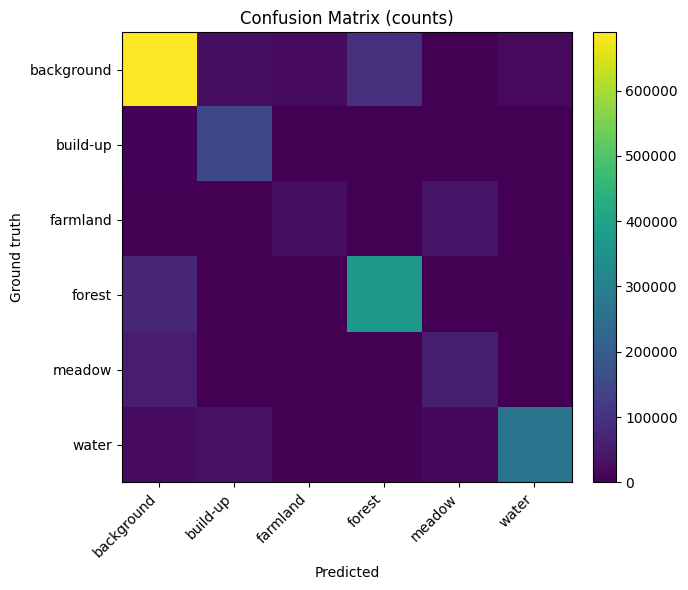

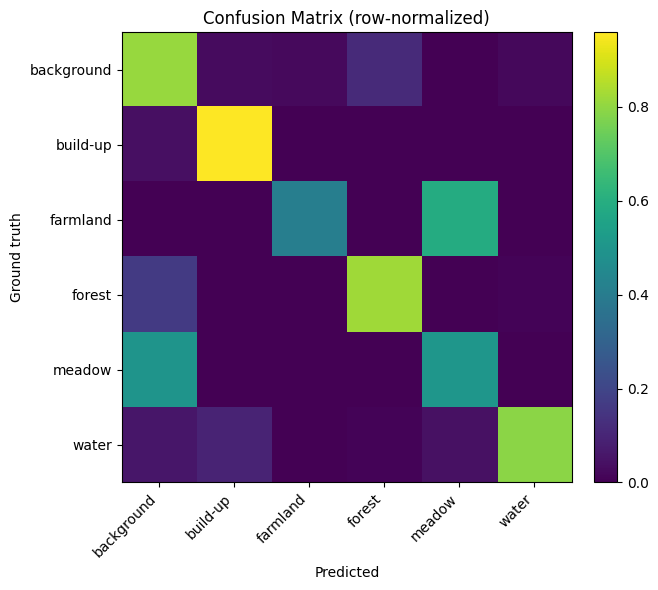

,class,support_px,PA,IoU,PA_%,IoU_%
0,background,851355,0.8094,0.6852,80.94,68.52
1,build-up,155304,0.9588,0.6988,95.88,69.88
2,farmland,65028,0.4101,0.3096,41.01,30.96
3,forest,445814,0.8217,0.6709,82.17,67.09
4,meadow,112099,0.5047,0.3372,50.47,33.72
5,water,336480,0.7928,0.7424,79.28,74.24


,metric,value,value_%
0,mIoU,0.5740,57.40
1,mPA,0.7162,71.62
2,OA,0.7905,79.05


Saved:
/content/swin_unet_respath_metrics_per_class.csv
/content/swin_unet_respath_metrics_summary.csv


In [ ]:
import pandas as pd

def plot_confusion_matrix(cm_np: np.ndarray, class_names, normalize=None, annotate=False):
    if normalize == 'true':
        sums = cm_np.sum(axis=1, keepdims=True)
        disp = cm_np / np.clip(sums, 1, None)
        title = "Confusion Matrix (row-normalized)"
    else:
        disp, title = cm_np, "Confusion Matrix (counts)"
    plt.figure(figsize=(7,6))
    im = plt.imshow(disp, cmap='viridis')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted"); plt.ylabel("Ground truth"); plt.title(title)
    if annotate:
        txt = disp if normalize=='true' else cm_np
        for i in range(disp.shape[0]):
            for j in range(disp.shape[1]):
                s = f"{txt[i,j]:.2f}" if normalize=='true' else f"{int(txt[i,j])}"
                plt.text(j, i, s, ha='center', va='center', color='w', fontsize=8)
    plt.tight_layout(); plt.show()

cm_np = cm.cpu().numpy()
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize=None, annotate=False)
plot_confusion_matrix(cm_np, CLASS_NAMES, normalize='true', annotate=False)

iou_list, miou, pa_list, mpa, oa = metrics_from_cm(cm)
support = cm.sum(dim=1).to(torch.int64).numpy()

df_per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support_px": support,
    "PA": np.array(pa_list, dtype=float),
    "IoU": np.array(iou_list, dtype=float),
})
df_per_class["PA_%"]  = (df_per_class["PA"]  * 100).round(2)
df_per_class["IoU_%"] = (df_per_class["IoU"] * 100).round(2)

df_summary = pd.DataFrame({
    "metric": ["mIoU", "mPA", "OA"],
    "value":  [miou,   mpa,   oa]
})
df_summary["value_%"] = (df_summary["value"] * 100).round(2)

from IPython.display import display
display(df_per_class[["class","support_px","PA","IoU","PA_%","IoU_%"]].round(4))
display(df_summary[["metric","value","value_%"]].round(4))

out_dir = "/content"
df_per_class.to_csv(f"{out_dir}/swin_unet_respath_metrics_per_class.csv", index=False)
df_summary.to_csv(f"{out_dir}/swin_unet_respath_metrics_summary.csv", index=False)
print("Saved:",
      f"{out_dir}/swin_unet_respath_metrics_per_class.csv",
      f"{out_dir}/swin_unet_respath_metrics_summary.csv", sep="\n")


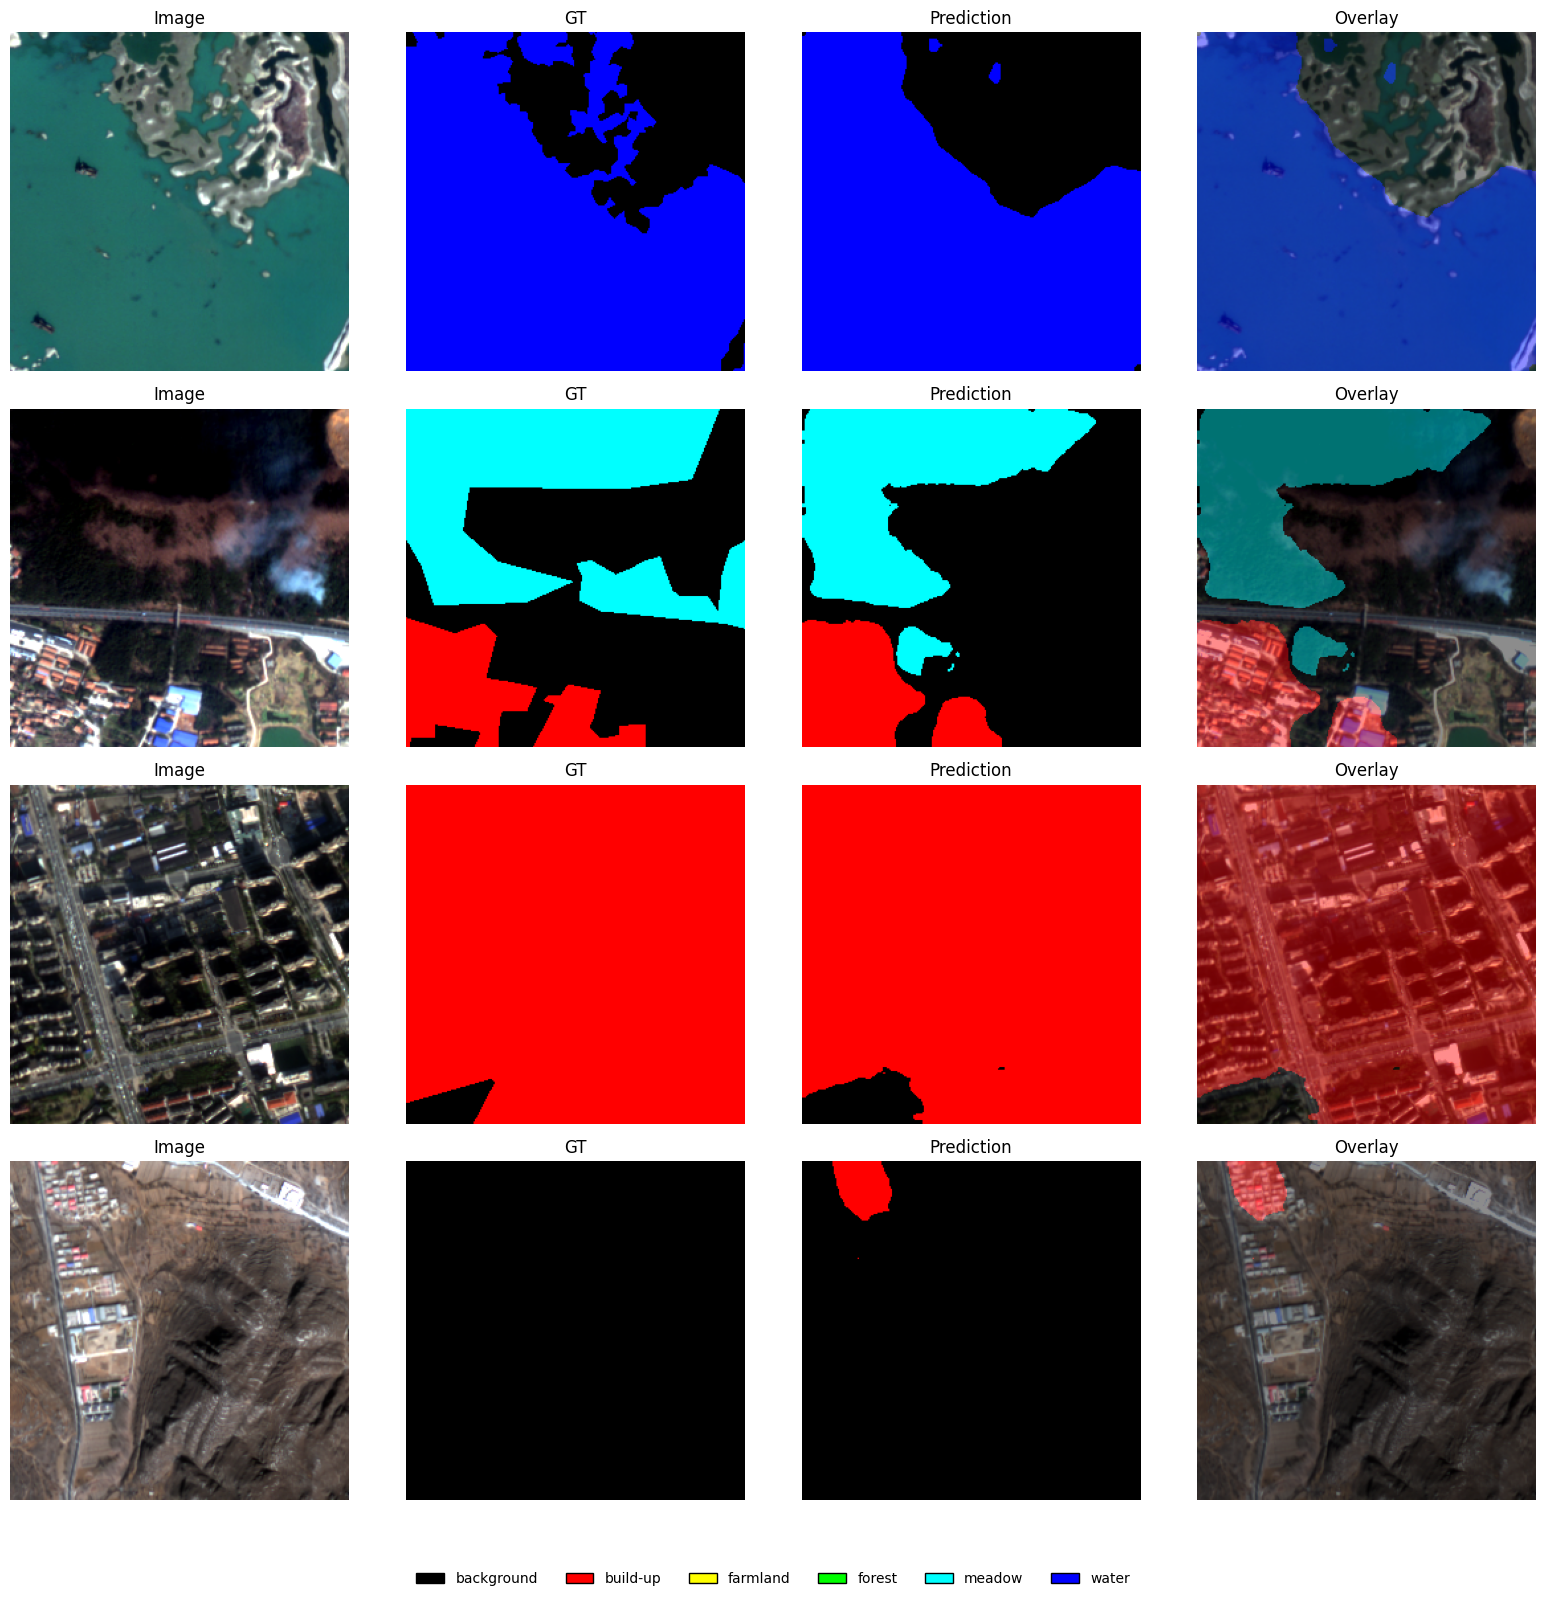

In [ ]:
from matplotlib.patches import Patch
def _get_logits_main(outputs):
    if isinstance(outputs, dict):
        return outputs.get("main", next(iter(outputs.values())))
    return outputs


@torch.no_grad()
def show_val_patches(model, val_loader, max_items=6, overlay_alpha=0.45):
    device = next(model.parameters()).device
    model.eval()
    xb, yb = next(iter(val_loader))
    xb = xb.to(device)
    with torch.autocast(device_type="cuda", enabled=True, dtype=torch.bfloat16):
        logits = model(xb)

    logits = _get_logits_main(logits)    
    if logits.ndim == 4:                 
        logits = logits.squeeze(0)
    pred = logits.argmax(1).detach().cpu().numpy()


    imgs = xb.cpu().permute(0,2,3,1).numpy()
    imgs = (imgs * NORM_STD + NORM_MEAN) * 255.0
    imgs = np.clip(imgs, 0, 255).astype(np.uint8)
    gts  = yb.numpy()

    n = min(len(imgs), max_items)
    fig, axs = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axs = axs[None,:]
    for i in range(n):
        im  = imgs[i]; gt = colorize_idx(gts[i]); pr = colorize_idx(pred[i])
        ovl = (im.astype(np.float32)*(1.0-overlay_alpha) + pr.astype(np.float32)*overlay_alpha).astype(np.uint8)
        axs[i,0].imshow(im);  axs[i,0].set_title("Image");      axs[i,0].axis('off')
        axs[i,1].imshow(gt);  axs[i,1].set_title("GT");         axs[i,1].axis('off')
        axs[i,2].imshow(pr);  axs[i,2].set_title("Prediction"); axs[i,2].axis('off')
        axs[i,3].imshow(ovl); axs[i,3].set_title("Overlay");    axs[i,3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()

show_val_patches(model, val_loader, max_items=6)


Found 30 val files


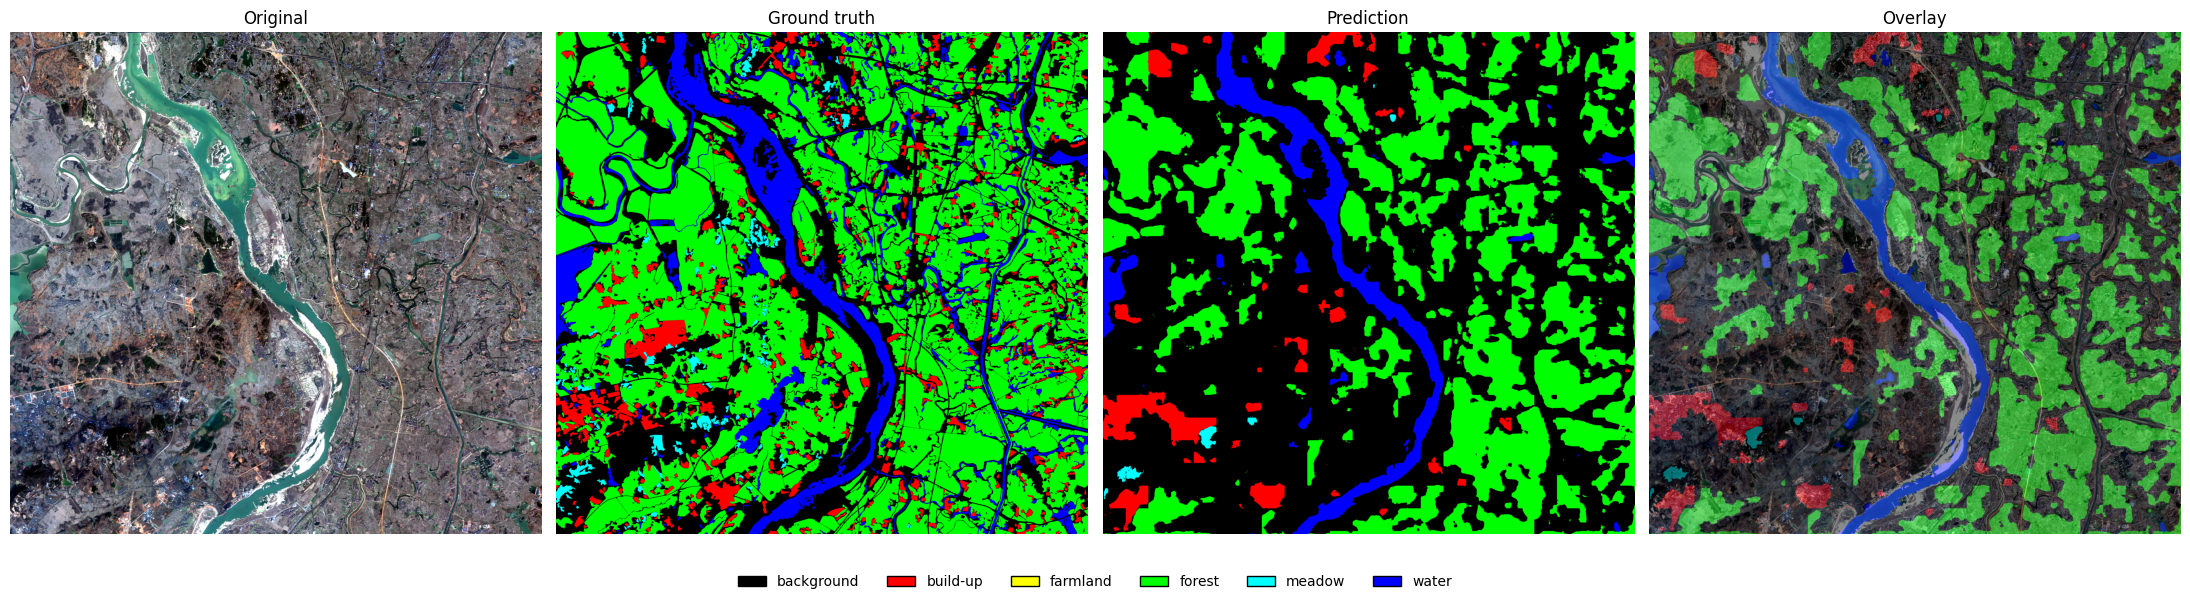

In [ ]:
@torch.no_grad()
def sliding_window_predict(model, image_path,
                           patch_size=256, stride=128,
                           device="cuda", accumulate_on="cpu",
                           downscale_long_side=3000, amp=True,
                           divisor=32):


    device_str = "cuda" if (device == "cuda" and torch.cuda.is_available()) else "cpu"
    dev = torch.device(device_str)
    acc_dev = torch.device("cpu") if accumulate_on == "cpu" else dev

   
    im = Image.open(image_path).convert("RGB")
    W0, H0 = im.size
    scale = 1.0
    if max(W0, H0) > downscale_long_side:
        scale = downscale_long_side / float(max(W0, H0))
        im = im.resize((int(W0*scale), int(H0*scale)), Image.BILINEAR)
    W, H = im.size

    def norm_np(a):
        return (a / 255.0 - NORM_MEAN) / NORM_STD

    score = torch.zeros((NUM_CLASSES, H, W), dtype=torch.float32, device=acc_dev)
    count = torch.zeros((1,          H, W), dtype=torch.float32, device=acc_dev)

    model = model.to(dev).eval()

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            patch = im.crop((x, y, min(x+patch_size, W), min(y+patch_size, H)))
            arr = norm_np(np.array(patch, np.uint8).astype(np.float32))
            ph, pw = arr.shape[:2]

            t = torch.from_numpy(arr).permute(2,0,1).unsqueeze(0).to(dev, non_blocking=True)

            pad_h = max(0, patch_size - ph)
            pad_w = max(0, patch_size - pw)
            if pad_h or pad_w:
                t = F.pad(t, (0, pad_w, 0, pad_h), mode="replicate")


        
            with torch.autocast(device_type=device_str,
                                enabled=(amp and device_str == "cuda"),
                                dtype=torch.bfloat16):  
                out = model(t)

        
            logits = _get_logits_main(out)

           
            if logits.ndim == 4:          
                logits = logits.squeeze(0)
            elif logits.ndim != 3:
                raise RuntimeError(f"Unexpected logits shape: {tuple(logits.shape)}")


            logits = logits[..., :ph, :pw].to(torch.float32)

     
            if acc_dev.type == "cpu":
                score[:, y:y+ph, x:x+pw] += logits.cpu()
                count[:, y:y+ph, x:x+pw] += 1.0
            else:
                score[:, y:y+ph, x:x+pw] += logits
                count[:, y:y+ph, x:x+pw] += 1.0

    
    score = score / torch.clamp(count, min=1.0)
    pred = torch.argmax(score, dim=0).cpu().numpy().astype(np.int64)

    
    if scale != 1.0:
        pred = np.array(
            Image.fromarray(pred.astype(np.uint8)).resize((W0, H0), Image.NEAREST),
            dtype=np.int64
        )
    return pred



def find_mask_path(img_path: Path, mask_dir: Path, suffix="_label"):
    stem = img_path.stem
    for ext in list(MASK_EXTS) + [img_path.suffix.lower()]:
        p = Path(mask_dir) / f"{stem}{suffix}{ext}"
        if p.exists(): return p
    for p in Path(mask_dir).glob(f"{stem}*label*"):
        if p.suffix.lower() in MASK_EXTS: return p
    raise FileNotFoundError(f"No mask for {img_path.name}")

def show_full_image_triptych(img_path: Path, mask_dir: Path, model, patch_size=256, stride=128,
                             downscale_long_side=3000):
    img_path = Path(img_path); mask_dir = Path(mask_dir)
    mask_path = find_mask_path(img_path, mask_dir, "_label")
    img_rgb = np.array(Image.open(img_path).convert("RGB"))
    gt_idx  = mask_to_class_any(Image.open(mask_path))
    pred_idx = sliding_window_predict(model, img_path, patch_size, stride,
                                      device="cuda", accumulate_on="cpu",
                                      downscale_long_side=downscale_long_side, amp=True)

    gt_rgb   = colorize_idx(gt_idx)
    pred_rgb = colorize_idx(pred_idx)
    overlay  = (img_rgb.astype(np.float32)*0.55 + pred_rgb.astype(np.float32)*0.45).astype(np.uint8)

    fig, axs = plt.subplots(1,4, figsize=(22,6))
    axs[0].imshow(img_rgb);  axs[0].set_title("Original"); axs[0].axis('off')
    axs[1].imshow(gt_rgb);   axs[1].set_title("Ground truth"); axs[1].axis('off')
    axs[2].imshow(pred_rgb); axs[2].set_title("Prediction");   axs[2].axis('off')
    axs[3].imshow(overlay);  axs[3].set_title("Overlay");      axs[3].axis('off')
    handles = [Patch(facecolor=np.array(c)/255.0, edgecolor='k', label=n)
               for c,n in zip(CLASS_COLORS, CLASS_NAMES)]
    fig.legend(handles=handles, loc="lower center", ncol=len(CLASS_NAMES), frameon=False)
    plt.tight_layout(rect=[0,0.05,1,1]); plt.show()


val_imgs = sorted([p for p in Path(VAL_IMG_DIR).iterdir() if p.suffix.lower() in IMG_EXTS])
print(f"Found {len(val_imgs)} val files")
show_full_image_triptych(val_imgs[0], VAL_MASK_DIR, model, patch_size=256, stride=128, downscale_long_side=3000)
